In [1]:
from google.colab import files
uploaded = files.upload()

Saving forest1.jpg to forest1.jpg
Saving forest2.jpg to forest2.jpg


forest1.jpg -> Vegetation Pixels: 784374, Coverage: 3.94%, Contour Area Sum: 407204.00


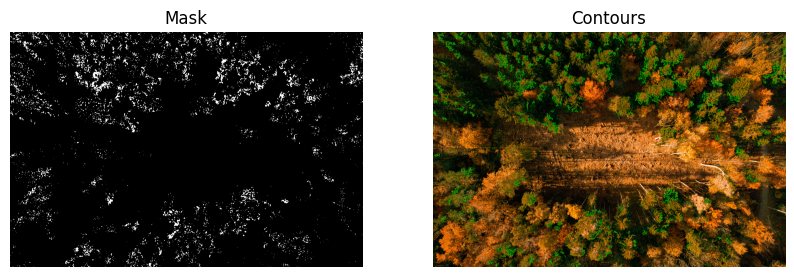

forest2.jpg -> Vegetation Pixels: 2977029, Coverage: 24.37%, Contour Area Sum: 3020732.00


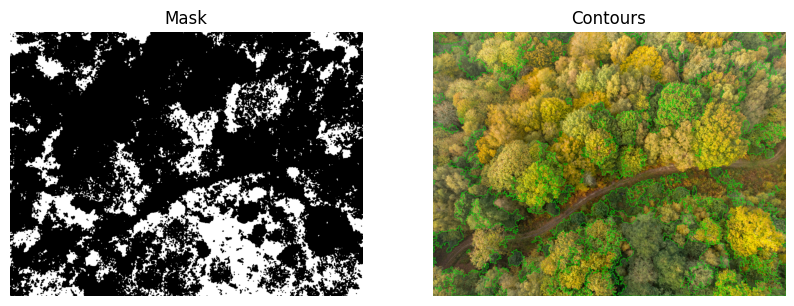

In [2]:
import cv2, numpy as np, matplotlib.pyplot as plt
import os

def process_image(filename):
    img = cv2.imread(filename)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])

    mask = cv2.inRange(hsv, lower_green, upper_green)

    # remove noise
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    total_area = 0
    out = img.copy()
    for c in contours:
        area = cv2.contourArea(c)
        if area > 500:
            total_area += area
            cv2.drawContours(out, [c], -1, (0,255,0), 2)

    veg_pixels = int(np.count_nonzero(mask))
    total_pixels = mask.shape[0] * mask.shape[1]
    percent = (veg_pixels/total_pixels) * 100

    print(f"{filename} -> Vegetation Pixels: {veg_pixels}, Coverage: {percent:.2f}%, Contour Area Sum: {total_area:.2f}")

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.title("Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Contours")
    plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

for f in uploaded.keys():
    process_image(f)